In [ ]:
%pip install mediapipe opencv-python scikit-learn torch pandas

Note: you may need to restart the kernel to use updated packages.


In [199]:
import mediapipe as mp
import cv2
import numpy as np
import uuid
import os
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [200]:
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

In [201]:
class Model(nn.Module):
    def __init__(self, in_features=8, h1=128, h2=64, out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [ ]:
path = '../data.csv'
df = pd.read_csv(path, header=None, names=['type', 'name', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4'])
df = df.drop('name', axis=1)
df

,type,x1,y1,x2,y2,x3,y3,x4,y4
0,hook_left,0.408374,0.723892,0.342853,0.461996,0.347841,0.928311,0.479606,0.587849
1,hook_left,0.407623,0.726216,0.343084,0.460443,0.347238,0.928308,0.481463,0.587591
2,hook_left,0.407343,0.726915,0.343206,0.459321,0.346806,0.928286,0.482602,0.587411
3,hook_left,0.407128,0.727550,0.343207,0.458430,0.346421,0.928293,0.482907,0.586750
4,hook_left,0.410367,0.715029,0.315134,0.530793,0.352404,0.914208,0.463075,0.584440
...,...,...,...,...,...,...,...,...,...
355,uppercut_right,0.232603,1.354104,0.924561,1.343756,0.265533,0.926430,0.877226,0.910894
356,uppercut_right,0.228808,1.352113,0.928423,1.347504,0.267640,0.927401,0.871602,0.911411
357,uppercut_right,0.237117,1.340811,0.931027,1.345228,0.269106,0.927067,0.875980,0.912012
358,uppercut_right,0.244255,1.330373,0.932539,1.348791,0.272872,0.920856,0.876815,0.912498


In [203]:
df['type'] = df['type'].replace('hook_left', 'hook')
df['type'] = df['type'].replace('hook_right', 'hook')
df['type'] = df['type'].replace('jab_left', 'jab')
df['type'] = df['type'].replace('jab_right', 'jab')
df['type'] = df['type'].replace('uppercut_left', 'uppercut')
df['type'] = df['type'].replace('uppercut_right', 'uppercut')
type_mapping = {'hook': 0, 'jab': 1, 'uppercut': 2}
df['type'] = df['type'].map(type_mapping)

X = np.array(df.drop('type', axis=1))
y = np.array(df['type'])

In [204]:
torch.manual_seed(24)
model = Model()
model

Model(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=3, bias=True)
)

In [205]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [206]:
# convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# convert y labels to long tensors (64-bit integers)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [207]:
# set criterion of model to measure error (how far off predictions are from data)
criterion = nn.CrossEntropyLoss()

# choose Adam Optimizer
# lr = learning rate (if error doesn't go down after a bunch of epochs, must lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# train our model
# epoch = one run through all training data in our network
epochs = 300
losses = []
for i in range(epochs):
  # go forward & get a prediction
  y_pred = model.forward(X_train) # get predicted results

  # measure loss/error, will be high at first
  loss = criterion(y_pred, y_train); # predicted vs training y

  # keep track of losses
  losses.append(loss.detach().numpy())
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 1.1016874313354492
Epoch: 10 and loss: 0.9557717442512512
Epoch: 20 and loss: 0.9016738533973694
Epoch: 30 and loss: 0.8606043457984924
Epoch: 40 and loss: 0.8066893815994263
Epoch: 50 and loss: 0.7335227727890015
Epoch: 60 and loss: 0.6529614925384521
Epoch: 70 and loss: 0.5512609481811523
Epoch: 80 and loss: 0.4871596693992615
Epoch: 90 and loss: 0.43390190601348877
Epoch: 100 and loss: 0.38735660910606384
Epoch: 110 and loss: 0.4014550447463989
Epoch: 120 and loss: 0.33264949917793274
Epoch: 130 and loss: 0.2990938425064087
Epoch: 140 and loss: 0.27436599135398865
Epoch: 150 and loss: 0.2532520890235901
Epoch: 160 and loss: 0.254265695810318
Epoch: 170 and loss: 0.23066282272338867
Epoch: 180 and loss: 0.20033961534500122
Epoch: 190 and loss: 0.24781830608844757
Epoch: 200 and loss: 0.20229271054267883
Epoch: 210 and loss: 0.17661812901496887
Epoch: 220 and loss: 0.15183700621128082
Epoch: 230 and loss: 0.1373528689146042
Epoch: 240 and loss: 0.12498818337917328
E

Text(0.5, 0, 'Epoch')

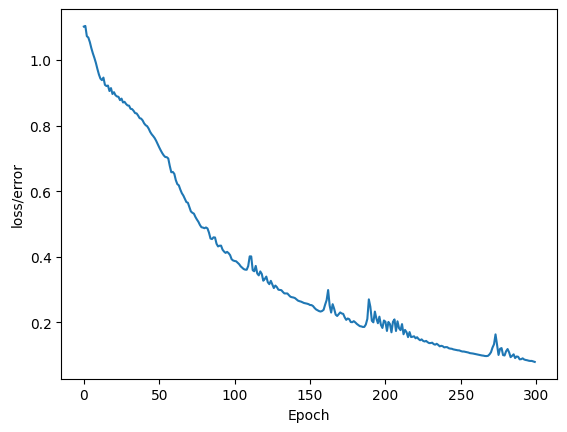

In [ ]:
# plot the losses
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("Epoch")

In [ ]:
# evaluate model on test data
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)

loss

tensor(0.1299)

In [ ]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = "hook"
    elif y_test[i] == 1:
      x = "uppercut"
    elif y_test[i] == 2:
      x = "jab"

    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We got {correct} out of {len(X_test)} correct.')

1.) tensor([-2.4918,  2.1162, -3.3048]) 	 1 	 1
2.) tensor([  4.3816,   9.9985, -16.5191]) 	 1 	 1
3.) tensor([ 2.3455, -1.4352, -3.3330]) 	 0 	 0
4.) tensor([ 4.6765, -1.9996, -3.3365]) 	 0 	 0
5.) tensor([ 3.1424, -3.2563, -2.7241]) 	 0 	 0
6.) tensor([ 3.1696, -3.0840, -2.9448]) 	 0 	 0
7.) tensor([ 2.8096,  0.5005, -4.3101]) 	 0 	 0
8.) tensor([-5.8332,  3.9745,  0.3428]) 	 1 	 1
9.) tensor([-0.5005,  2.1660, -5.8034]) 	 1 	 1
10.) tensor([-1.4792,  1.5525, -4.2836]) 	 1 	 1
11.) tensor([ 5.8259, -6.8480, -0.1116]) 	 0 	 0
12.) tensor([-2.2865,  1.7816, -3.1131]) 	 1 	 1
13.) tensor([-1.7460, -2.2897,  0.2537]) 	 2 	 2
14.) tensor([-8.7282,  4.5250,  1.7925]) 	 1 	 1
15.) tensor([  3.4735,   6.3782, -11.4245]) 	 1 	 1
16.) tensor([  4.9272,  11.0949, -18.3684]) 	 1 	 1
17.) tensor([-3.3695, -0.7715,  3.8949]) 	 2 	 2
18.) tensor([ 4.2216,  2.6789, -8.0937]) 	 1 	 0
19.) tensor([-1.5159, -7.7071,  7.3442]) 	 2 	 2
20.) tensor([-1.4422,  1.3382, -4.0463]) 	 1 	 1
21.) tensor([  3.388